# Bank Marketing - Feature Engineering

**DATA 4950 Week 7 Demo**

## What We Will Cover
1. Load preprocessed data
2. Create new features (ratios, bins, interactions)
3. Encode categorical features
4. Scale numerical features
5. Feature selection
6. Handle class imbalance (SMOTE)
7. Save final data for modeling

In [1]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

## 1. Load and Quick Prep

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')
print(f'X_train Loaded: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train Loaded: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test Loaded: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test Loaded: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

X_train Loaded: 32,940 rows x 19 columns
y_train Loaded: 32,940 rows x 1 columns
X_test Loaded: 8,236 rows x 19 columns
y_test Loaded: 8,236 rows x 1 columns


In [3]:
X_train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,48,technician,married,professional.course,no,yes,no,cellular,jul,mon,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
1,45,blue-collar,single,high.school,unknown,yes,no,cellular,may,mon,6,999,1,failure,-1.8,92.893,-46.2,1.244,5099.1
2,40,admin.,married,university.degree,no,no,no,cellular,aug,wed,2,999,1,failure,-2.9,92.201,-31.4,0.884,5076.2
3,47,retired,single,basic.6y,unknown,no,no,cellular,jul,mon,5,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
4,56,blue-collar,married,high.school,unknown,yes,no,telephone,jun,fri,3,999,0,nonexistent,1.4,94.465,-41.8,4.967,5228.1


In [4]:
## check column types

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f'Numerical ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical ({len(categorical_cols)}): {categorical_cols}')

Numerical (9): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [5]:
y_train

,y
0,1
1,0
2,0
3,0
4,0
...,...
32935,0
32936,0
32937,0
32938,1


## 2. Create New Features

Feature engineering adds **domain knowledge** to help the model.  
We create features on both train and test using the **same logic**.

### 2.1 Binning — Age Groups

In [6]:
age_bins = [0, 30, 40, 50, 60, 100]
age_labels = ['young', 'middle', 'senior', 'older', 'olderly']

# TODO: create age groups
X_train['age_groups'] = pd.cut(X_train['age'], bins= age_bins, labels=age_labels)
print('Age groups created:')
print(X_train['age_groups'].value_counts().sort_index())

Age groups created:
age_groups
young       5978
middle     13062
senior      8197
older       4974
olderly      729
Name: count, dtype: int64


In [7]:
X_test['age_groups'] = pd.cut(X_test['age'], bins= age_bins, labels=age_labels)
print(X_test['age_groups'].value_counts().sort_index())

age_groups
young      1403
middle     3318
senior     2040
older      1295
olderly     180
Name: count, dtype: int64


### 2.2 Ratio Features

In [8]:
# TODO: campaign intensity: how many calls relative to previous campaigns
# campaign_intensity = campaign /(previous +1 )

X_train['campaign_intensity'] = X_train['campaign']/(X_train['previous']+1)
X_test['campaign_intensity'] = X_test['campaign']/(X_test['previous']+1)

print('Create: campaign_intensity')
print(f'Mean: {X_train['campaign_intensity'].mean():.2f}')

Create: campaign_intensity
Mean: 2.13


### 2.3 Interaction Features

In [9]:
# economic pressure: combine employment rate with consumer confidence

X_train['econ_pressure'] = X_train['emp.var.rate']*X_train['cons.conf.idx']
X_test['econ_pressure'] = X_test['emp.var.rate']*X_test['cons.conf.idx']

print('Create: econ_pressure')

Create: econ_pressure


In [10]:
## TODO: contact vs economic conditions
# campaign x euribor3m

X_train['campaign_x_euribor'] = X_train['campaign']*X_train['euribor3m']
X_test['campaign_x_euribor'] = X_test['campaign']*X_test['euribor3m']


print('Create: campaign_x_euribor')

Create: campaign_x_euribor


### 2.4 Flag Features

Create binary (0/1) flags

In [11]:
## was client contacted before? (pdays=999 means never contacted)

X_train['was_contacted_before'] = (X_train['pdays']!=999).astype(int)
X_test['was_contacted_before'] = (X_test['pdays']!=999).astype(int)

print('Create: was_contacted_before')
print(f'Previously contacted: {X_train['was_contacted_before'].mean()*100:.1f}%')

Create: was_contacted_before
Previously contacted: 3.7%


In [12]:
# TODO: many campaign contacts (contacted more than 3 times)

X_train['many_contacts'] = (X_train['campaign']>3).astype(int)
X_test['many_contacts'] = (X_test['campaign']>3).astype(int)

print('Create: many_contacts')
print(f'Previously contacted: {X_train['many_contacts'].mean()*100:.1f}%')

Create: many_contacts
Previously contacted: 18.6%


#### 2.5 Log Transform

Skewed features

In [14]:
## log transform of campaign
log_campaign1 = np.log1p(X_train['campaign'])
log_campaign2 = np.log(X_train['campaign']+1)
print(f'difference: {((log_campaign1-log_campaign2)**2).sum()}')

difference: 0.0


In [15]:
X_train['log_campaign'] = np.log1p(X_train['campaign'])

print('Created: log_campaign')

Created: log_campaign


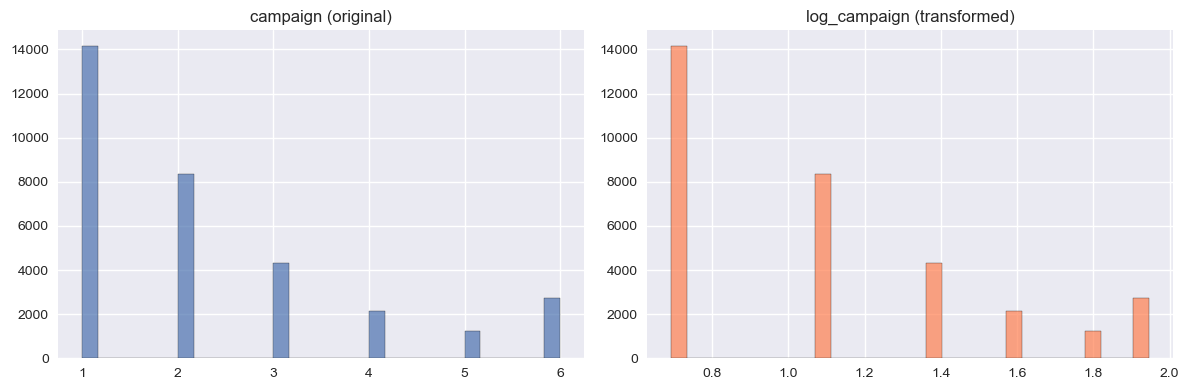

In [16]:
# compare original vs log transform

fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].hist(X_train['campaign'],bins=30,edgecolor='black',alpha=0.7)
axes[0].set_title('campaign (original)')

axes[1].hist(X_train['log_campaign'],bins=30,edgecolor='black',alpha=0.7, color='coral')
axes[1].set_title('log_campaign (transformed)')
plt.tight_layout()
plt.show()

In [17]:
X_train = X_train.drop(['log_campaign'],axis=1)

In [18]:
new_features = ['age_grouped','campaign_intensity','econ_pressure','campaign_x_euribor',
               'was_contacted_before','many_contacts']

print(f'Created {len(new_features)} new features:')
for f in new_features:
    print(f'{f}')


print(f'\nTotal features now: {X_train.shape[1]}')

Created 6 new features:
age_grouped
campaign_intensity
econ_pressure
campaign_x_euribor
was_contacted_before
many_contacts

Total features now: 25


### 3. Encode Categorical Features

Convert categorical columns to numbers so the model can use them.

**Strategy:**
- **Ordinal encoding** for features with natural order (education)
- **One-hot encoding** for nominal features (no natural order)

In [19]:
# check categorical columns
for col in categorical_cols:
    print(f'{col}: {X_train[col].nunique()} unique -> {X_train[col].unique()}')

job: 11 unique -> ['technician' 'blue-collar' 'admin.' 'retired' 'management'
 'self-employed' 'services' 'student' 'entrepreneur' 'housemaid'
 'unemployed']
marital: 3 unique -> ['married' 'single' 'divorced']
education: 7 unique -> ['professional.course' 'high.school' 'university.degree' 'basic.6y'
 'basic.9y' 'basic.4y' 'illiterate']
default: 3 unique -> ['no' 'unknown' 'yes']
housing: 2 unique -> ['yes' 'no']
loan: 2 unique -> ['no' 'yes']
contact: 2 unique -> ['cellular' 'telephone']
month: 10 unique -> ['jul' 'may' 'aug' 'jun' 'nov' 'sep' 'oct' 'mar' 'apr' 'dec']
day_of_week: 5 unique -> ['mon' 'wed' 'fri' 'tue' 'thu']
poutcome: 3 unique -> ['nonexistent' 'failure' 'success']


#### 3.1 Ordinal Encoding - Education

In [20]:
X_train['education'].value_counts()

education
university.degree      11071
high.school             7626
basic.9y                4846
professional.course     4165
basic.4y                3359
basic.6y                1859
illiterate                14
Name: count, dtype: int64

In [21]:
## TODO: Ordinal encoding for education

X_train['education'] = X_train['education'].replace('illiterate', 'basic.4y')
X_test['education'] = X_test['education'].replace('illiterate', 'basic.4y')

education_order =['basic.4y', 'basic.6y', 'basic.9y', 'high.school',
                  'professional.course'  ,'university.degree']

In [23]:
from sklearn.preprocessing import OrdinalEncoder


ord_encoder = OrdinalEncoder(categories=[education_order],handle_unknown='use_encoded_value',
                            unknown_value=-1)

X_train['education_encoded'] = ord_encoder.fit_transform(X_train[['education']])
X_test['education_encoded'] = ord_encoder.transform(X_test[['education']])

print('Education encoding:')
for i, level in enumerate(education_order):
    print(f'{level} -> {i}')

Education encoding:
basic.4y -> 0
basic.6y -> 1
basic.9y -> 2
high.school -> 3
professional.course -> 4
university.degree -> 5


#### 3.2 One-Hot Encoding - Nominal Categories

In [ ]:
nominal_cols = []
for col in categorical_cols:
    if col!='education':
        nominal_cols.append(col)

nominal_cols.append('age_groups')
print(f'nomical columns: {nominal_cols}')

In [ ]:
# apply one-hot encoding using pd.get_dummies
# drop_first=True to avoid multicollinearity (dummy variable trap)


# For X_train
job_dummies_train = pd.get_dummies(X_train['job'], prefix='job', drop_first=True,dtype=int)
X_train_example = pd.concat([X_train, job_dummies_train], axis=1)
X_train_example = X_train_example.drop('job', axis=1)
X_train_example

In [ ]:
# TODO: For X_test (same steps)



In [ ]:
## TODO: multi-columns one-hot encoding



In [ ]:
X_train

In [ ]:
X_test = pd.get_dummies(X_test, columns= nominal_cols, drop_first= True, dtype=int)

X_test

In [ ]:
# ensure both have the same columns (test might be missing some categories)
X_train,X_test = X_train.align(X_test, join='left', axis=1, fill_value = 0)

print(f'After encoding - X_train: {X_train.shape}, X_trest: {X_test.shape}')

In [ ]:
## drop original education column (we have education_encoded now)
X_train = X_train.drop('education', axis=1)
X_test = X_test.drop('education', axis=1)

In [ ]:
print(f'\nAll columns now numeric: {X_train.select_dtypes(include="object").columns.tolist()}')

### 4. Scale Numerical Features

Scaling ensures all features are on the same range so no single feature dominates.

**Important:** Fit the scaler on **training data only**, then transform both train and test.

In [ ]:
# identify columns to scale (original numerical + new numerical features)
# we do NOT scale binary/one-hot encoded columns (they are already 0/1)


cols_to_scale = numerical_cols + ['campaign_intensity','econ_pressure',
                                  'campaign_x_euribor','education_encoded']
print(f'Columns to scale ({len(cols_to_scale)}): {cols_to_scale}')

In [ ]:
# TODO: fit on training data, transfrom both train and test

from sklearn.preprocessing import StandardScaler




print('Scaling complete')
print(f'\n Sample mean (should be ~0 for train):')
print(X_train[cols_to_scale].mean().round(4).head())
print(f'\n Sample stds (should be ~1 for train):')
print(X_train[cols_to_scale].std().round(4).head())

In [ ]:
X_train.dtypes

## 5. Feature Selection

Remove features that don't help the model. We'll use correlation analysis to check for:
1. **Low correlation with target** → feature may not be useful
2. **High correlation between features** → redundant (multicollinearity)

In [ ]:
## TODO: compute correlation_matrix





In [ ]:
print("Correlations with Target (y):")
correlations = correlation_matrix['y'].abs().sort_values(ascending=False)
correlations = correlations.drop('y')
correlations

In [ ]:
print('Top 15 features correlated with target:')
print(correlations.head(15).round(4))
print(f'\nBottom 5:')
print(correlations.tail(5).round(4))

In [ ]:
# TODO: visualize top 15 feature correlations with target





plt.xlabel('Absolute Correlation with Target')
plt.title('Top 15 Features - Correlation with Deposit (y)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# find pairs with absolute correlation > 0.8
correlation_matrix_abs = correlation_matrix.abs()
high_corr_pairs = []
for i in range(len(X_train.columns)):
    for j in range (i+1, len(X_train.columns)):
        if correlation_matrix_abs.iloc[i,j]>0.8:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i,j]))

In [ ]:
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df = high_corr_df.sort_values(by="Correlation", ascending=False).reset_index(drop=True)

print("Highly correlated feature pairs (>0.8):")
high_corr_df

In [ ]:
high_corr_df.sort_values(by='Feature 1')

In [ ]:
# flatten y_train if needed

y_train_flat = y_train.values.ravel()

In [ ]:
campaign_features = ['campaign', 'campaign_intensity', 'campaign_x_euribor', 'many_contacts']
economic_features = ['emp.var.rate', 'euribor3m', 'nr.employed', 'econ_pressure']
contact_features = ['pdays', 'was_contacted_before']

for name, features in [('Campaign', campaign_features), 
                        ('Economic', economic_features),
                        ('Contact', contact_features)]:
    print(f'\n{name} cluster:')
    for col in features:
        corr = abs(X_train[col].corr(pd.Series(y_train_flat, index=X_train.index)))
        print(f'  {col}: {corr:.4f}')

Based on the correlation analysis:
- **Keep** features with meaningful correlation to target
- **Remove** one from each highly correlated pair (keep the one more correlated with target)
- Use domain knowledge + correlation to make final decisions

> **Note:** For this demo, we'll keep all features and let the model handle it. In practice, you may want to drop redundant features to reduce overfitting.

## 6. Handle Class Imbalance (SMOTE)

⚠️ **Critical Rules:**
1. Apply ONLY to **training data** (NEVER to test data!)
2. Apply AFTER all preprocessing and feature engineering
3. Apply INSIDE cross-validation folds in practice

SMOTE = Synthetic Minority Oversampling Technique  
It creates synthetic samples of the minority class by interpolating between existing minority samples.

In [ ]:
# TODO: check class distribution before SMOTE



print(f'Imbalance ratio: {imbalance_ratio:.1f}:1')

In [ ]:
# TODO: apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=4950)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_flat)

In [ ]:
print('After SMOTE:')
print(f'  Class 0 (no deposit):  {(y_train_smote == 0).sum():,}')
print(f'  Class 1 (yes deposit): {(y_train_smote == 1).sum():,}')
imbalance_ratio = (y_train_smote == 0).sum() / (y_train_smote == 1).sum()
print(f'Imbalance ratio: {imbalance_ratio:.1f}:1')
print(f'\n  X_train shape: {X_train.shape} → {X_train_smote.shape}')

In [ ]:
# visualize before vs after SMOTE

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No (0)', 'Yes (1)'], [(y_train_flat==0).sum(), (y_train_flat==1).sum()], 
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

axes[1].bar(['No (0)', 'Yes (1)'], [(y_train_smote==0).sum(), (y_train_smote==1).sum()], 
            color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 7. Save Final Data for Modeling

We save **two versions** of training data:
- **Without SMOTE** — for models that handle imbalance internally (e.g., `class_weight='balanced'`)
- **With SMOTE** — for models that need balanced data

In [ ]:
import os

os.makedirs('../data/modeling', exist_ok=True)

## save WITHOUT SMOTE
X_train.to_csv('../data/modeling/X_train.csv', index=False)
X_test.to_csv('../data/modeling/X_test.csv', index=False)
pd.Series(y_train_flat).to_csv('../data/modeling/y_train.csv', index=False)
y_test.to_csv('../data/modeling/y_test.csv', index=False)

## save WITH SMOTE
X_train_smote.to_csv('../data/modeling/X_train_smote.csv', index=False)
pd.Series(y_train_smote).to_csv('../data/modeling/y_train_smote.csv', index=False)

print('Saved to ../data/modeling/')
print(f'  X_train:       {X_train.shape}')
print(f'  X_train_smote: {X_train_smote.shape}')
print(f'  X_test:        {X_test.shape}')

## Summary

### Feature Created:

- 

### Processing Applied:
- 
- 
- 
- 

### Datasets:
- **X_train/y_train** 
- **X_train_smote/y_train_smote** 
- **X_test/y_test** 